11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9252 - loss: 0.2541 - val_accuracy: 0.9657 - val_loss: 0.1223
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9670 - loss: 0.1079 - val_accuracy: 0.9732 - val_loss: 0.0912
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9772 - loss: 0.0743 - val_accuracy: 0.9742 - val_loss: 0.0907
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9827 - loss: 0.0555 - val_accuracy: 0.9773 - val_loss: 0.0816
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9858 - loss: 0.0437 - val_accuracy: 0.9795 - val_loss: 0.0806
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9885 - loss: 0.0352 - val_accuracy: 0.9730 - val_loss: 0.1010
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9905 - loss: 0.0290 - val_accuracy: 0.9790 - val_loss: 0.0863
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9920 - loss: 0.0256 

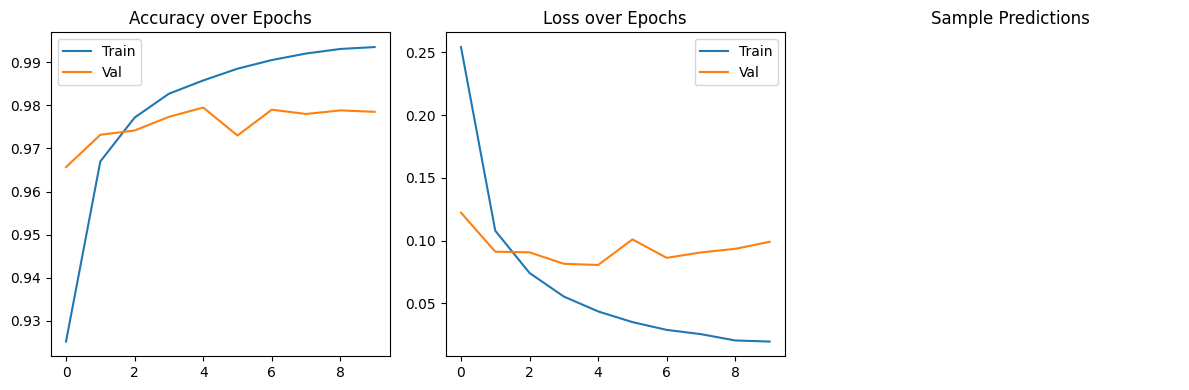

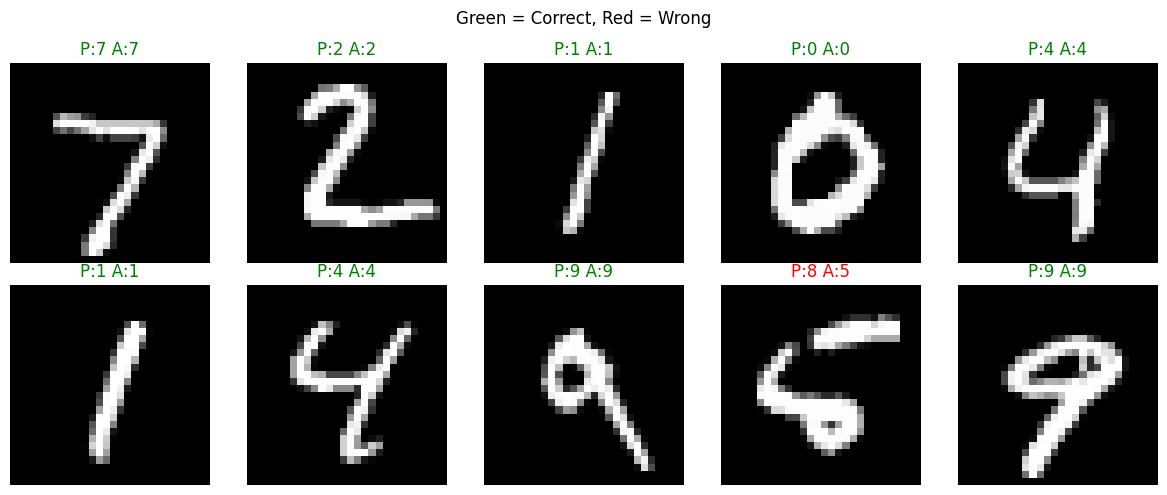

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import numpy as np

# Load & preprocess
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 784) / 255.0
x_test  = x_test.reshape(-1, 784)  / 255.0

# Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64,  activation='relu'),
    Dense(10,  activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss over Epochs')
plt.legend()

# Predictions visualization
predictions = np.argmax(model.predict(x_test), axis=1)

plt.subplot(1, 3, 3)
plt.axis('off')
plt.title('Sample Predictions')
plt.tight_layout()
plt.show()

# Show 10 sample predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predictions[i] == y_test[i] else 'red'
    ax.set_title(f"P:{predictions[i]} A:{y_test[i]}", color=color)
    ax.axis('off')
plt.suptitle('Green = Correct, Red = Wrong')
plt.tight_layout()
plt.show()